## How to Extract Coorindates from Mapping API
## Advandatges
 #You do not need to got to the locations to get the GPS
 #Convenitent when you need coordinates in bulk with some specific catgories
## Disadvantage
 #It work based on the tag name, if a shop or does not use your assigned tag, it might not be pulled

In [11]:
! pip install googlemaps

import csv
import googlemaps

# Set up your API key
api_key = 'your API key'  ### YOU have to put your GOOGLE API HERE
gmaps = googlemaps.Client(key=api_key)

# Define the list of shop categories
shop_categories = ['grocery', 'restaurant', 'pharmacy']  ## Change your categories

# Define the search query for each category and retrieve coordinates
results = []
for category in shop_categories:
    query = f'{category} shop in Ann Arbor'
    places = gmaps.places(query=query)

    for place in places['results']:
        name = place['name']
        location = place['geometry']['location']
        lat = location['lat']
        lng = location['lng']
        exact_location = place.get('formatted_address', '')
        results.append([name, lat, lng, category, exact_location])

# Define the output CSV file path
output_file = r'D:\Python for GIS\shop_coordinates_with_location.csv'

# Write the data to the CSV file
with open(output_file, 'w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['Name', 'Latitude', 'Longitude', 'Category', 'Exact Location'])  # Header row
    writer.writerows(results)

print(f"Data saved successfully to {output_file}")


Data saved successfully to D:\Python for GIS\shop_coordinates_with_location.csv


## Lets Have a Quick Check-- Map the collected corrdinates

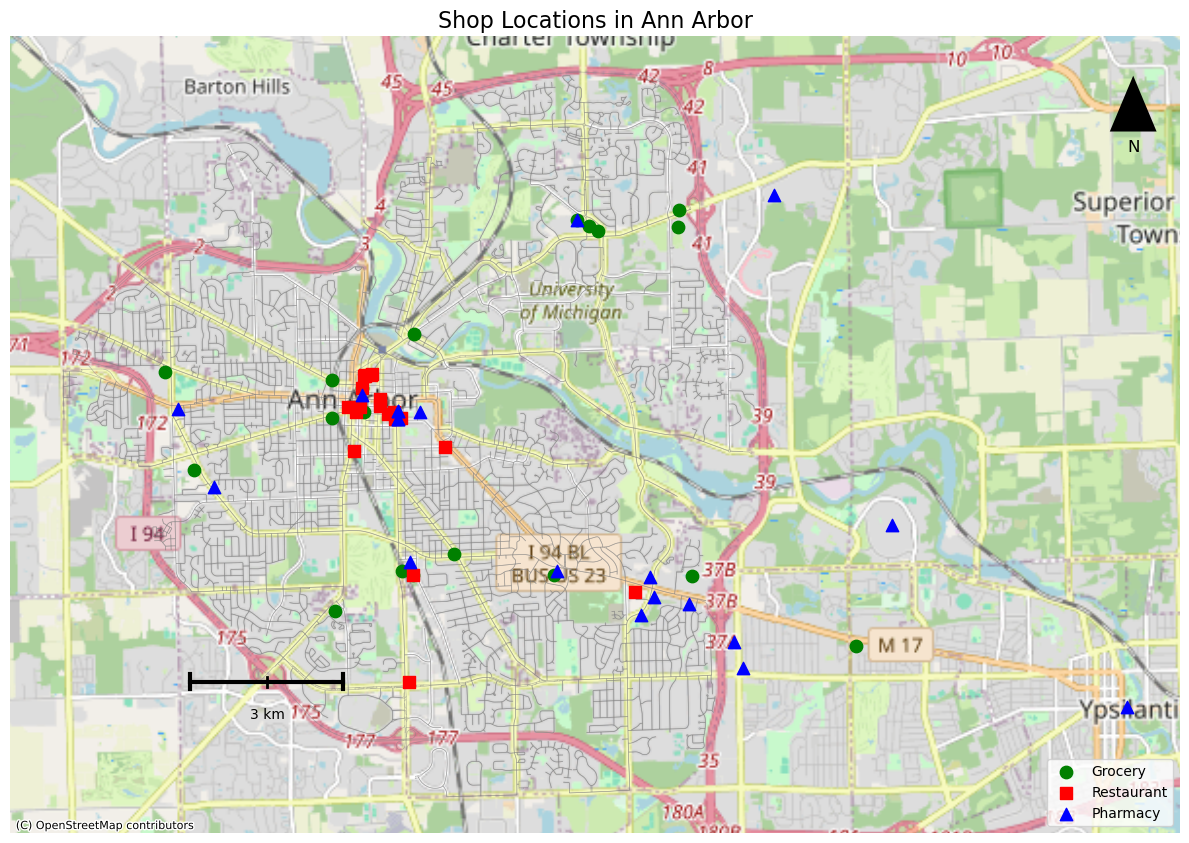

Map saved successfully to D:\Python for GIS\mapped_shops_ann_arbor.png


In [25]:
! pip install geopandas osmnx matplotlib contextily shapely
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import osmnx as ox
from shapely.geometry import Point
import contextily as ctx
import matplotlib.patches as mpatches
import matplotlib.patches as patches

# Load the CSV
csv_path = r'D:\Python for GIS\shop_coordinates_with_location.csv'
df = pd.read_csv(csv_path)

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']),
    crs="EPSG:4326"
)

# Project to Web Mercator
gdf = gdf.to_crs(epsg=3857)

# Get Ann Arbor road network
graph = ox.graph_from_place("Ann Arbor, Michigan, USA", network_type='drive')
edges = ox.graph_to_gdfs(graph, nodes=False)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 10))

# Plot road network
edges.to_crs(epsg=3857).plot(ax=ax, linewidth=0.5, color='gray', alpha=0.5, zorder=1)

# Define colors and markers for each category
styles = {
    'grocery':   {'color': 'green', 'marker': 'o'},
    'restaurant': {'color': 'red', 'marker': 's'},
    'pharmacy':  {'color': 'blue', 'marker': '^'}
}

# Plot each category
for cat, style in styles.items():
    subset = gdf[gdf['Category'].str.lower() == cat]
    subset.plot(
        ax=ax,
        color=style['color'],
        marker=style['marker'],
        markersize=80,
        label=cat.capitalize(),
        zorder=2
    )

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=12)

# === Custom North Arrow (triangular) ===
# Triangle defined in axes coordinates
triangle = patches.Polygon(
    [[0.94, 0.88], [0.96, 0.95], [0.98, 0.88]],  # triangle points
    closed=True,
    transform=ax.transAxes,
    facecolor='black'
)
ax.add_patch(triangle)
ax.text(0.96, 0.87, 'N', transform=ax.transAxes, ha='center', va='top', fontsize=12)

# === Custom Scale Bar (3 km) at bottom ===
# Determine coordinates for scale bar (bottom left corner)
xmin, ymin, xmax, ymax = gdf.total_bounds
scalebar_length = 3000  # in meters
bar_x = xmin + 500
bar_y = ymin + 500

# Draw the horizontal line
ax.plot([bar_x, bar_x + scalebar_length], [bar_y, bar_y], color='black', linewidth=3, zorder=3)

# Draw vertical end caps and center tick
cap_height = 300
# Left cap
ax.plot([bar_x, bar_x], [bar_y - cap_height/2, bar_y + cap_height/2], color='black', linewidth=3, zorder=3)
# Center tick
ax.plot([bar_x + scalebar_length/2]*2, [bar_y - cap_height/3, bar_y + cap_height/3], color='black', linewidth=2, zorder=3)
# Right cap
ax.plot([bar_x + scalebar_length, bar_x + scalebar_length], [bar_y - cap_height/2, bar_y + cap_height/2], color='black', linewidth=3, zorder=3)

# Add scale label
ax.text(bar_x + scalebar_length / 2, bar_y - 500, '3 km', ha='center', va='top', fontsize=10)

# Final adjustments
ax.set_title("Shop Locations in Ann Arbor", fontsize=16)
ax.set_axis_off()
ax.legend(loc='lower right')
plt.tight_layout()

# Save output
output_path = r'D:\Python for GIS\mapped_shops_ann_arbor.png'
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Map saved successfully to {output_path}")


In [29]:
## You can customize your map using python or in ArcGIS